# Prédiction de la Valeur Marchande des Joueurs de Football
## Mini Projet Machine Learning — 1ère MR-BC | 2025/2026
### Responsable : Dr. Fadoua BOUAFIF

---

> **Contexte :** Une entreprise de scouting footballistique souhaite automatiser l'évaluation des joueurs afin d'optimiser ses décisions de transfert. Notre mission est de construire un modèle de Machine Learning capable de prédire la valeur marchande d'un joueur à partir de ses statistiques (performances, âge, position, club, etc.).

**Modèles comparés :**
- Régression Linéaire
- Random Forest Regressor

---
## 1. Import des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(" Toutes les bibliothèques importées avec succès !")

 Toutes les bibliothèques importées avec succès !


---
## 2. Chargement du Dataset

In [2]:
# Chargement du dataset
df = pd.read_csv('man_players_24.csv', low_memory=False)

print(f" Dimensions du dataset : {df.shape}")
print(f" Colonnes disponibles : {list(df.columns[:20])} ...")
df.head(3)

 Dimensions du dataset : (180021, 109)
 Colonnes disponibles : ['player_id', 'player_url', 'fifa_version', 'fifa_update', 'update_as_of', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg', 'club_team_id', 'club_name', 'league_id', 'league_name'] ...


,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,...,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,...,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,...,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3


---
## 3. Exploration & Analyse des données (EDA)

In [3]:
# Informations générales
print("=" * 50)
print(" INFORMATIONS GÉNÉRALES")
print("=" * 50)
df.info()

print("\n=" * 50)
print(" STATISTIQUES DESCRIPTIVES")
print("=" * 50)
df.describe()

 INFORMATIONS GÉNÉRALES
<class 'pandas.DataFrame'>
RangeIndex: 180021 entries, 0 to 180020
Columns: 109 entries, player_id to gk
dtypes: float64(20), int64(43), str(46)
memory usage: 149.7 MB

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
 STATISTIQUES DESCRIPTIVES


,player_id,fifa_version,fifa_update,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,...,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed
count,180021.000000,180021.000000,180021.0,180021.000000,180021.000000,1.778680e+05,178173.00000,180021.000000,180021.000000,180021.000000,...,147133.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,180021.000000,20024.000000
mean,217326.670294,19.621450,2.0,65.712711,70.779581,2.379142e+06,10638.01081,25.138689,181.287061,75.233356,...,57.837807,45.851456,47.759511,45.764783,16.509979,16.260136,16.129902,16.276951,16.615517,38.750300
std,35215.749284,2.838621,0.0,7.018104,6.255569,6.184358e+06,21637.41400,4.679389,6.764179,6.999181,...,12.305995,20.452502,21.309061,20.899683,17.661659,16.846583,16.499513,17.009393,17.971201,10.578237
min,2.000000,15.000000,2.0,40.000000,40.000000,1.000000e+03,500.00000,16.000000,154.000000,49.000000,...,3.000000,1.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000
25%,200759.000000,17.000000,2.0,61.000000,66.000000,3.250000e+05,2000.00000,21.000000,176.000000,70.000000,...,50.000000,26.000000,27.000000,25.000000,8.000000,8.000000,8.000000,8.000000,8.000000,30.000000
50%,222734.000000,20.000000,2.0,66.000000,71.000000,7.500000e+05,4000.00000,25.000000,181.000000,75.000000,...,59.000000,51.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000,40.000000
75%,239858.000000,22.000000,2.0,70.000000,75.000000,1.800000e+06,10000.00000,28.000000,186.000000,80.000000,...,66.000000,63.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000,46.000000
max,278145.000000,24.000000,2.0,94.000000,95.000000,1.940000e+08,575000.00000,54.000000,208.000000,110.000000,...,96.000000,94.000000,94.000000,95.000000,91.000000,92.000000,95.000000,92.000000,94.000000,68.000000


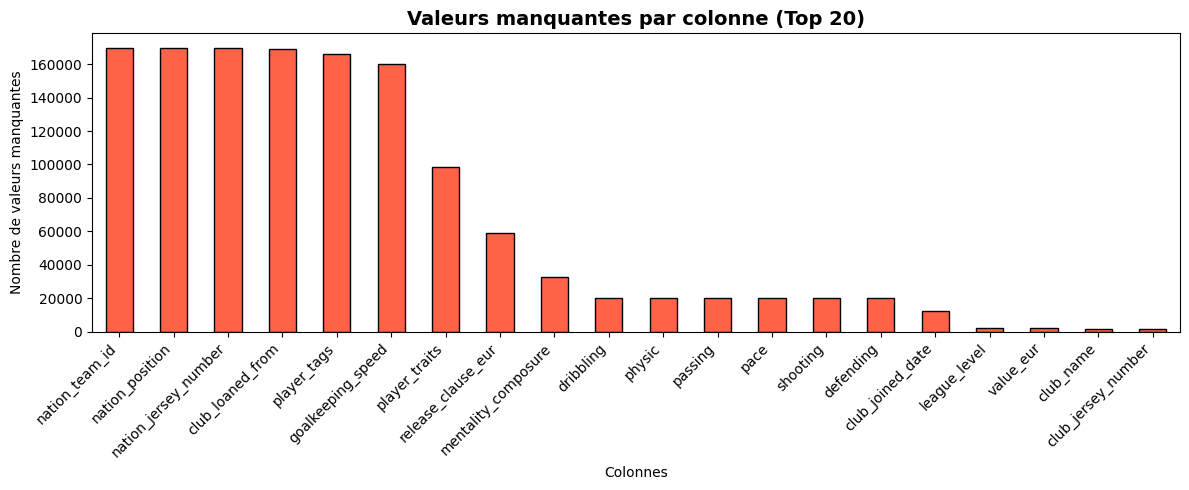

In [4]:
# Valeurs manquantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 5))
missing.head(20).plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Valeurs manquantes par colonne (Top 20)', fontsize=14, fontweight='bold')
plt.xlabel('Colonnes')
plt.ylabel('Nombre de valeurs manquantes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

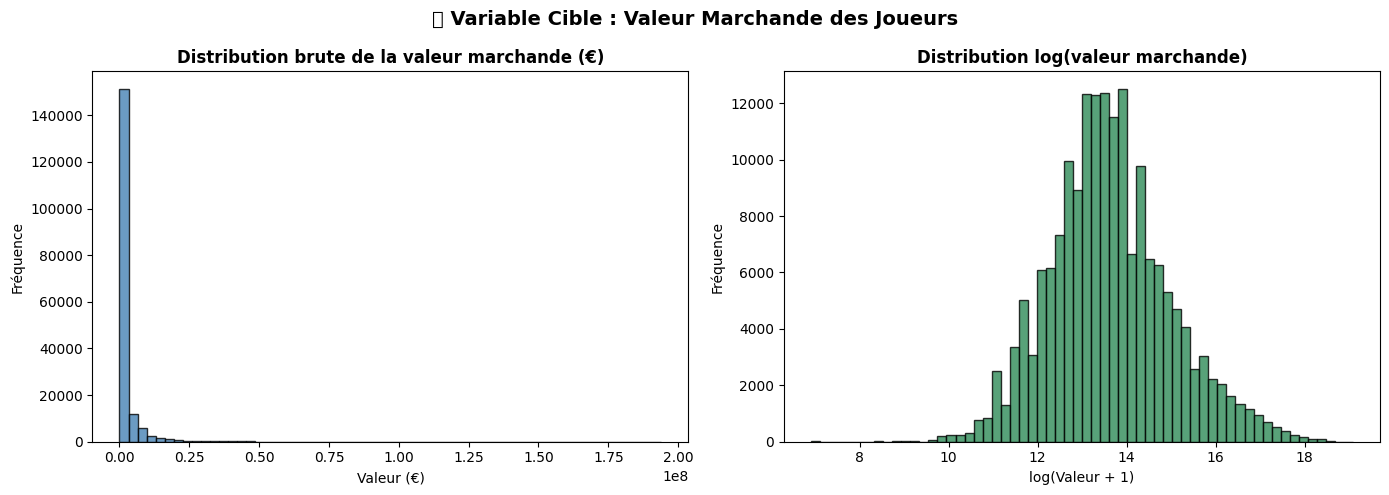

 Valeur médiane : 750,000 €
 Valeur max     : 194,000,000 €
 Valeur min     : 1,000 €


In [5]:
# Distribution de la variable cible : value_eur
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution brute
axes[0].hist(df['value_eur'].dropna(), bins=60, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution brute de la valeur marchande (€)', fontweight='bold')
axes[0].set_xlabel('Valeur (€)')
axes[0].set_ylabel('Fréquence')

# Distribution log
log_vals = np.log1p(df['value_eur'].dropna())
axes[1].hist(log_vals, bins=60, color='seagreen', edgecolor='black', alpha=0.8)
axes[1].set_title('Distribution log(valeur marchande)', fontweight='bold')
axes[1].set_xlabel('log(Valeur + 1)')
axes[1].set_ylabel('Fréquence')

plt.suptitle(' Variable Cible : Valeur Marchande des Joueurs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f" Valeur médiane : {df['value_eur'].median():,.0f} €")
print(f" Valeur max     : {df['value_eur'].max():,.0f} €")
print(f" Valeur min     : {df['value_eur'].min():,.0f} €")

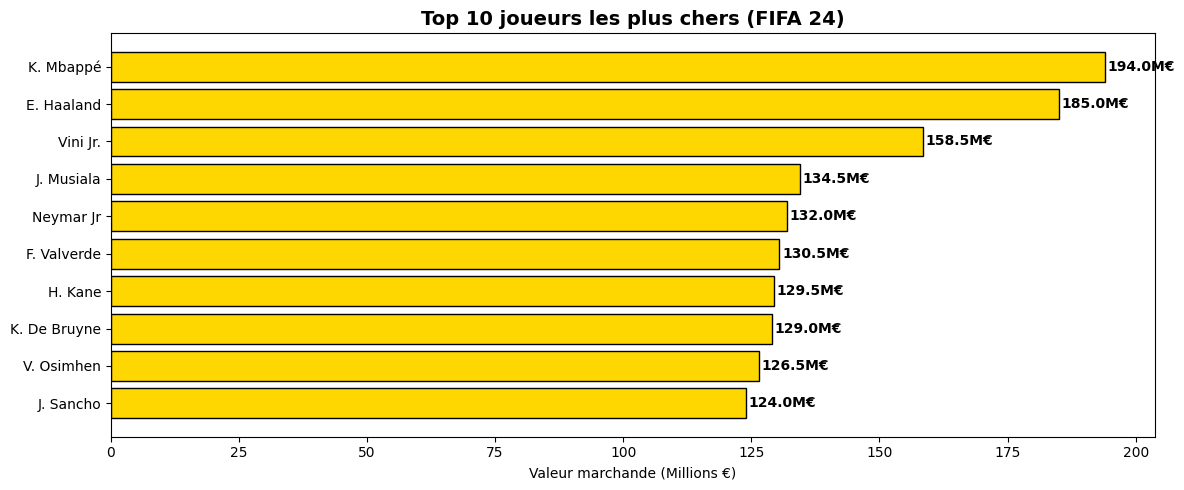

In [6]:
# Top 10 joueurs les plus chers
top10 = (
    df.sort_values('value_eur', ascending=False)
    .drop_duplicates(subset='short_name')
    .head(10)
    [['short_name', 'club_name', 'overall', 'age', 'value_eur']]
)
top10['value_eur_M'] = (top10['value_eur'] / 1e6).round(1)

plt.figure(figsize=(12, 5))
bars = plt.barh(top10['short_name'], top10['value_eur_M'], color='gold', edgecolor='black')
plt.xlabel('Valeur marchande (Millions €)')
plt.title('Top 10 joueurs les plus chers (FIFA 24)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for bar, val in zip(bars, top10['value_eur_M']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val}M€', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

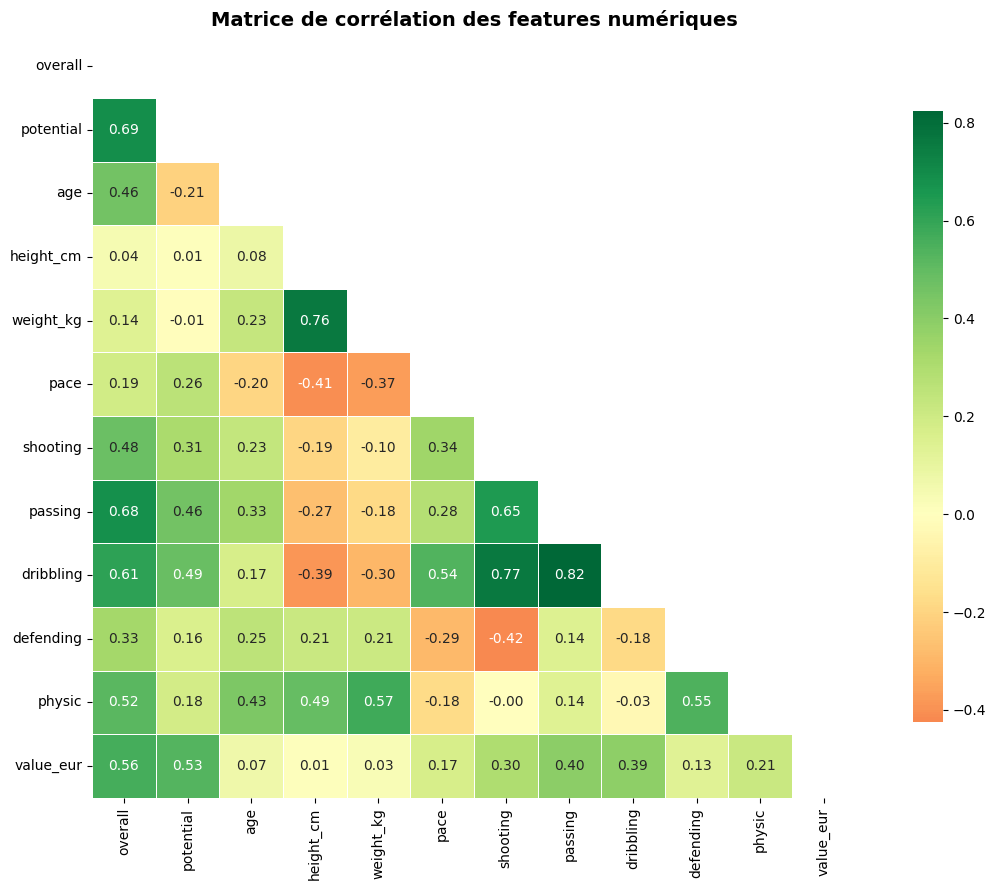

In [7]:
# Matrice de corrélation
numeric_cols = ['overall', 'potential', 'age', 'height_cm', 'weight_kg',
                'pace', 'shooting', 'passing', 'dribbling', 'defending',
                'physic', 'value_eur']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation des features numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Préparation des données (Feature Engineering)

In [8]:
# Sélection des features pertinentes
features = [
    'overall', 'potential', 'age', 'height_cm', 'weight_kg',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'international_reputation', 'skill_moves', 'weak_foot',
    'league_level', 'club_team_id'
]
target = 'value_eur'

# Filtrer les données
df_clean = df[features + [target]].dropna()

# Transformation log de la cible (pour réduire le skew)
df_clean['log_value'] = np.log1p(df_clean[target])

print(f" Dataset nettoyé : {df_clean.shape[0]} joueurs, {len(features)} features")

 Dataset nettoyé : 157768 joueurs, 16 features


In [9]:
# Séparation features / cible
X = df_clean[features]
y = df_clean['log_value']

# Split train/test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f" Train : {X_train.shape[0]} joueurs")
print(f" Test  : {X_test.shape[0]} joueurs")

# Standardisation pour la Régression Linéaire
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

 Train : 126214 joueurs
 Test  : 31554 joueurs


---
## 5. Modèle 1 — Régression Linéaire 

In [10]:
# Entraînement
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Prédictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Métriques
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
cv_lr   = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='r2').mean()

print("=" * 45)
print(" RÉGRESSION LINÉAIRE — Résultats")
print("=" * 45)
print(f"  MAE  : {mae_lr:.4f}")
print(f"  RMSE : {rmse_lr:.4f}")
print(f"  R²   : {r2_lr:.4f}")
print(f"  CV R²: {cv_lr:.4f}")

 RÉGRESSION LINÉAIRE — Résultats
  MAE  : 0.2805
  RMSE : 0.3605
  R²   : 0.9277
  CV R²: 0.9264


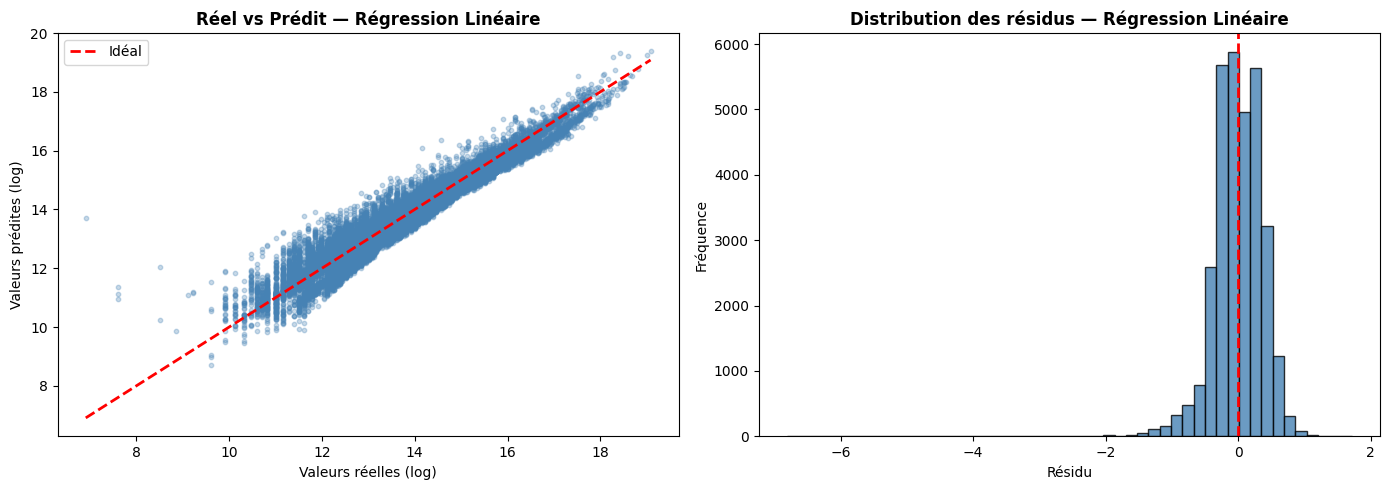

In [11]:
# Visualisation : Valeurs réelles vs prédites
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred_lr, alpha=0.3, color='steelblue', s=10)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2, label='Idéal')
axes[0].set_xlabel('Valeurs réelles (log)')
axes[0].set_ylabel('Valeurs prédites (log)')
axes[0].set_title('Réel vs Prédit — Régression Linéaire', fontweight='bold')
axes[0].legend()

# Résidus
residuals = y_test - y_pred_lr
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Résidu')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des résidus — Régression Linéaire', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Modèle 2 — Random Forest

In [12]:
# Entraînement
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)

# Métriques
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
cv_rf   = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2').mean()

print("=" * 45)
print(" RANDOM FOREST — Résultats")
print("=" * 45)
print(f"  MAE  : {mae_rf:.4f}")
print(f"  RMSE : {rmse_rf:.4f}")
print(f"  R²   : {r2_rf:.4f}")
print(f"  CV R²: {cv_rf:.4f}")

 RANDOM FOREST — Résultats
  MAE  : 0.2266
  RMSE : 0.2860
  R²   : 0.9545
  CV R²: 0.9539


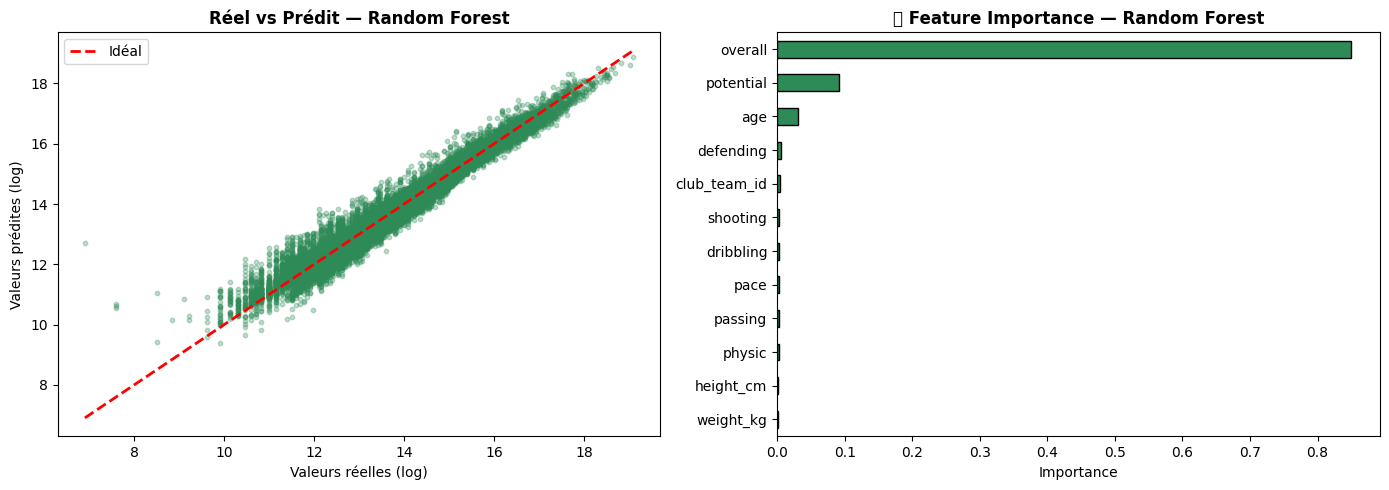

In [13]:
# Visualisation Random Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred_rf, alpha=0.3, color='seagreen', s=10)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2, label='Idéal')
axes[0].set_xlabel('Valeurs réelles (log)')
axes[0].set_ylabel('Valeurs prédites (log)')
axes[0].set_title('Réel vs Prédit — Random Forest', fontweight='bold')
axes[0].legend()

# Feature importance
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
importances.tail(12).plot(kind='barh', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title(' Feature Importance — Random Forest', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

---
## 7. Comparaison des deux modèles 

In [14]:
# Tableau comparatif
results = pd.DataFrame({
    'Modèle'     : ['Régression Linéaire', 'Random Forest'],
    'MAE'        : [round(mae_lr, 4),  round(mae_rf, 4)],
    'RMSE'       : [round(rmse_lr, 4), round(rmse_rf, 4)],
    'R²'         : [round(r2_lr, 4),   round(r2_rf, 4)],
    'CV R² (5-fold)': [round(cv_lr, 4), round(cv_rf, 4)]
})

print("\n" + "=" * 65)
print(" TABLEAU COMPARATIF DES MODÈLES")
print("=" * 65)
print(results.to_string(index=False))


 TABLEAU COMPARATIF DES MODÈLES
             Modèle    MAE   RMSE     R²  CV R² (5-fold)
Régression Linéaire 0.2805 0.3605 0.9277          0.9264
      Random Forest 0.2266 0.2860 0.9545          0.9539


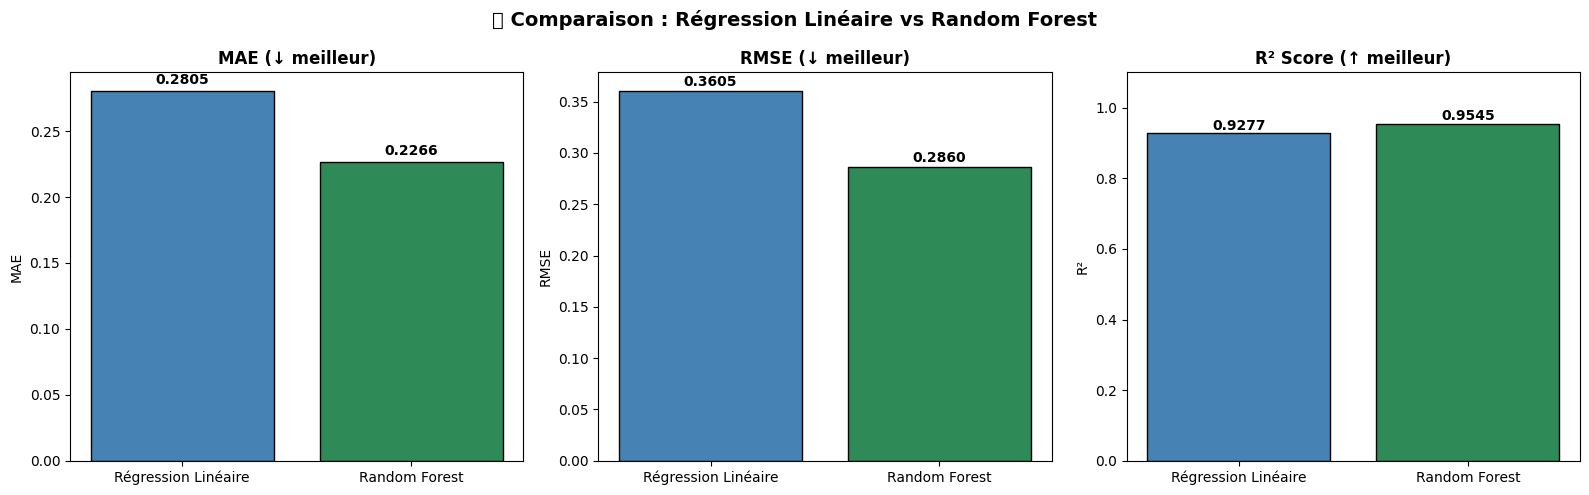

In [15]:
# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = ['Régression Linéaire', 'Random Forest']
colors = ['steelblue', 'seagreen']

# MAE
axes[0].bar(models, [mae_lr, mae_rf], color=colors, edgecolor='black')
axes[0].set_title('MAE (↓ meilleur)', fontweight='bold')
axes[0].set_ylabel('MAE')
for i, v in enumerate([mae_lr, mae_rf]):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# RMSE
axes[1].bar(models, [rmse_lr, rmse_rf], color=colors, edgecolor='black')
axes[1].set_title('RMSE (↓ meilleur)', fontweight='bold')
axes[1].set_ylabel('RMSE')
for i, v in enumerate([rmse_lr, rmse_rf]):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# R²
axes[2].bar(models, [r2_lr, r2_rf], color=colors, edgecolor='black')
axes[2].set_title('R² Score (↑ meilleur)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1.1)
for i, v in enumerate([r2_lr, r2_rf]):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle(' Comparaison : Régression Linéaire vs Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Prédictions sur les 10 premiers joueurs du test set
sample = X_test.head(10).copy()
sample_scaled = scaler.transform(sample)

pred_lr_sample = np.expm1(lr_model.predict(sample_scaled))
pred_rf_sample = np.expm1(rf_model.predict(sample))
real_vals      = np.expm1(y_test.head(10).values)

comparison = pd.DataFrame({
    'Valeur Réelle (€)'      : real_vals.astype(int),
    'Pred Rég. Linéaire (€)' : pred_lr_sample.astype(int),
    'Pred Random Forest (€)' : pred_rf_sample.astype(int),
})

print("\n Exemples de prédictions (10 joueurs du test set) :")
print(comparison.to_string())


 Exemples de prédictions (10 joueurs du test set) :
   Valeur Réelle (€)  Pred Rég. Linéaire (€)  Pred Random Forest (€)
0             549999                  683849                  697671
1             139999                  197972                  176279
2              60000                   95588                   66259
3            1200000                 1510780                 1333891
4            3299999                 4051284                 4098328
5            6499999                 9420044                 6359970
6             725000                 1097785                  835545
7             700000                 1015082                  948427
8             349999                  258275                  281151
9             800000                  618885                  704616


---
## 8. Conclusion

| Critère | Régression Linéaire | Random Forest |
|---|---|---|
| Complexité | Simple | Modéré |
| Interprétabilité |  Haute |  Moyenne |
| Performance |  Limitée |  Élevée |
| Gestion des non-linéarités |  Non |  Oui |
| Temps d'entraînement |  Rapide |  Plus lent |
